# 📊 NEPSE Stock Prediction with Sentiment Analysis
## Combining LSTM Price Prediction with News Sentiment

This notebook integrates:
1. **Historical price data** (OHLC)
2. **News sentiment analysis** (using TextBlob & VADER)
3. **LSTM model predictions**
4. **Combined prediction signals**

In [1]:
# Install required packages
!pip install textblob vaderSentiment newspaper3k beautifulsoup4 selenium pandas numpy scikit-learn tensorflow matplotlib seaborn
!python -c "import nltk; nltk.download('punkt'); nltk.download('vader_lexicon')"

     ------------------------------------ 126.0/126.0 kB 618.8 kB/s eta 0:00:00
     -------------------------------------- 211.1/211.1 kB 1.8 MB/s eta 0:00:00
     -------------------------------------- 294.9/294.9 kB 2.6 MB/s eta 0:00:00
     ---------------------------------------- 4.0/4.0 MB 5.7 MB/s eta 0:00:00
     ---------------------------------------- 81.5/81.5 kB ? eta 0:00:00
     ------------------------------------ 105.9/105.9 kB 877.5 kB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     ---------------------------------------- 7.4/7.4 MB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for tinysegmenter: filename

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\choba\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\choba\AppData\Roaming\nltk_data...


In [2]:
# Core imports
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Sentiment Analysis
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Web Scraping
from selenium import webdriver
from selenium.webdriver.common.by import By
from bs4 import BeautifulSoup
import time
import requests

# Machine Learning
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model
import tensorflow as tf

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

print("✅ All packages imported successfully!")
print(f"📅 Current Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ All packages imported successfully!
📅 Current Date: 2026-02-07 13:48:29


## 🔧 Configuration

In [3]:
# Configuration
CONFIG = {
    'COMPANY_SYMBOL': 'ADBL',  # Change this for different stocks
    'MODEL_PATH': 'best_lstm_stock_model.h5',  # Your trained model
    'STOCK_DATA_PATH': 'crest.csv',  # Your stock price CSV
    'SEQUENCE_LENGTH': 60,  # Days of history for LSTM
    'NEWS_LOOKBACK_DAYS': 30,  # How many days of news to analyze
    'SENTIMENT_WEIGHT': 0.3,  # How much to weight sentiment (0-1)
    'PRICE_WEIGHT': 0.7  # How much to weight LSTM prediction (0-1)
}

print("Configuration loaded:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Configuration loaded:
  COMPANY_SYMBOL: ADBL
  MODEL_PATH: best_lstm_stock_model.h5
  STOCK_DATA_PATH: crest.csv
  SEQUENCE_LENGTH: 60
  NEWS_LOOKBACK_DAYS: 30
  SENTIMENT_WEIGHT: 0.3
  PRICE_WEIGHT: 0.7


## 📰 STEP 1: News Scraping & Collection

In [13]:
from selenium import webdriver
from selenium.webdriver.common.by import By
import time
import pandas as pd
from datetime import datetime, timedelta
import random

# 🔥 SENTIMENT IMPORTS (MISSING BEFORE)
from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer

# Initialize sentiment analyzer
vader_analyzer = SentimentIntensityAnalyzer()


def scrape_nepse_news(company_symbol="ADBL", days=30):
    all_news = []

    print(f"\n🕷️ Scraping NEPSE general news & filtering for {company_symbol}...")

    try:
        driver = webdriver.Edge()
        driver.get("https://www.sharesansar.com/news")
        time.sleep(5)

        for _ in range(4):
            driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
            time.sleep(2)

        news_blocks = driver.find_elements(By.XPATH, "//a[contains(@href,'/news')]")
        print(f"  🔎 Raw news links found: {len(news_blocks)}")

        for item in news_blocks:
            text = item.text.strip()
            if len(text) < 20:
                continue

            if company_symbol.lower() in text.lower():
                all_news.append({
                    "date": datetime.now().strftime("%Y-%m-%d"),
                    "headline": text,
                    "source": "ShareSansar"
                })

        driver.quit()

    except Exception as e:
        print("  ⚠️ Live scraping failed")

    # =====================================================
    # 🔥 FALLBACK DUMMY NEWS
    # =====================================================
    if len(all_news) == 0:
        print("  ⚠️ No real news found — inserting dummy fallback news")

        dummy_templates = [
            f"{company_symbol} announces quarterly financial performance update",
            f"{company_symbol} board approves strategic operational decision",
            f"{company_symbol} reports steady growth in recent fiscal period",
            f"{company_symbol} sees increased investor interest in NEPSE trading",
            f"{company_symbol} management highlights future expansion plans"
        ]

        for i in range(5):
            all_news.append({
                "date": (datetime.now() - timedelta(days=i)).strftime("%Y-%m-%d"),
                "headline": random.choice(dummy_templates),
                "source": "Dummy"
            })

    print(f"  ✅ Final news count: {len(all_news)}")
    return all_news


# ============================
# RUN SCRAPER
# ============================
print("=" * 70)
print("📰 NEWS SCRAPING")
print("=" * 70)

company_symbol = "NICA"
news_data = scrape_nepse_news(company_symbol, 30)

# ✅ FIXED VARIABLE NAME
news_df = pd.DataFrame(news_data)

print("\n📋 Sample news:")
print(news_df.head(10))


# ============================
# SENTIMENT FUNCTIONS
# ============================
def analyze_sentiment_textblob(text):
    try:
        return TextBlob(text).sentiment.polarity
    except:
        return 0.0


def analyze_sentiment_vader(text):
    try:
        return vader_analyzer.polarity_scores(text)['compound']
    except:
        return 0.0


def classify_sentiment(score):
    if score > 0.1:
        return 'Positive', '🟢'
    elif score < -0.1:
        return 'Negative', '🔴'
    else:
        return 'Neutral', '⚪'


# ============================
# SENTIMENT ANALYSIS
# ============================
print("=" * 70)
print("🧠 SENTIMENT ANALYSIS")
print("=" * 70)

if not news_df.empty:
    news_df['sentiment_textblob'] = news_df['headline'].apply(analyze_sentiment_textblob)
    news_df['sentiment_vader'] = news_df['headline'].apply(analyze_sentiment_vader)

    news_df['sentiment_score'] = (
        news_df['sentiment_textblob'] + news_df['sentiment_vader']
    ) / 2

    news_df['sentiment_label'] = news_df['sentiment_score'].apply(
        lambda x: classify_sentiment(x)[0]
    )
    news_df['sentiment_emoji'] = news_df['sentiment_score'].apply(
        lambda x: classify_sentiment(x)[1]
    )

    print("\n📊 Sentiment Distribution:")
    print(news_df['sentiment_label'].value_counts())

    news_df.to_csv(f"{company_symbol}_news_sentiment.csv", index=False)
    print(f"\n💾 Saved: {company_symbol}_news_sentiment.csv")

else:
    print("\n⚠️ No news available for sentiment analysis")


📰 NEWS SCRAPING

🕷️ Scraping NEPSE general news & filtering for NICA...
  🔎 Raw news links found: 7
  ⚠️ No real news found — inserting dummy fallback news
  ✅ Final news count: 5

📋 Sample news:
         date                                           headline source
0  2026-02-07  NICA management highlights future expansion plans  Dummy
1  2026-02-06  NICA announces quarterly financial performance...  Dummy
2  2026-02-05  NICA reports steady growth in recent fiscal pe...  Dummy
3  2026-02-04  NICA reports steady growth in recent fiscal pe...  Dummy
4  2026-02-03  NICA announces quarterly financial performance...  Dummy
🧠 SENTIMENT ANALYSIS

📊 Sentiment Distribution:
sentiment_label
Neutral     3
Positive    2
Name: count, dtype: int64

💾 Saved: NICA_news_sentiment.csv


## 📈 STEP 3: Load Stock Price Data & LSTM Model

In [14]:
print("="*70)
print("📈 LOADING STOCK DATA & MODEL")
print("="*70)

# Load stock price data
print("\n[1/3] Loading stock price data...")
stock_df = pd.read_csv(CONFIG['STOCK_DATA_PATH'])

# Clean and prepare data
stock_df['Date'] = pd.to_datetime(stock_df['Date'])
stock_df['Close'] = pd.to_numeric(stock_df['Close'].str.replace(',', ''), errors='coerce')
stock_df = stock_df.dropna(subset=['Close'])
stock_df = stock_df.sort_values('Date')

print(f"  ✅ Loaded {len(stock_df)} price records")
print(f"  Date range: {stock_df['Date'].min()} to {stock_df['Date'].max()}")
print(f"  Current price: Rs. {stock_df['Close'].iloc[-1]:,.2f}")

# Load LSTM model
print("\n[2/3] Loading LSTM model...")
try:
    model = load_model(CONFIG['MODEL_PATH'])
    print(f"  ✅ Model loaded from {CONFIG['MODEL_PATH']}")
except Exception as e:
    print(f"  ⚠️  Model loading failed: {e}")
    model = None

# Prepare data for prediction
print("\n[3/3] Preparing data for prediction...")
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(stock_df[['Close']].values)

# Get last 60 days for prediction
sequence_length = CONFIG['SEQUENCE_LENGTH']
last_sequence = scaled_data[-sequence_length:]
X_pred = last_sequence.reshape(1, sequence_length, 1)

print(f"  ✅ Prepared sequence of {sequence_length} days")
print(f"  ✅ Ready for prediction")

📈 LOADING STOCK DATA & MODEL

[1/3] Loading stock price data...
  ✅ Loaded 169 price records
  Date range: 2025-04-10 00:00:00 to 2026-01-12 00:00:00
  Current price: Rs. 1,240.00

[2/3] Loading LSTM model...


  ✅ Model loaded from best_lstm_stock_model.h5

[3/3] Preparing data for prediction...
  ✅ Prepared sequence of 60 days
  ✅ Ready for prediction


## 🔮 STEP 4: Make Predictions with Sentiment

In [15]:
print("="*70)
print("🔮 PREDICTION WITH SENTIMENT INTEGRATION")
print("="*70)

if model is not None:
    # LSTM prediction
    print("\n[1/3] Making LSTM prediction...")
    lstm_pred_scaled = model.predict(X_pred, verbose=0)
    lstm_prediction = scaler.inverse_transform(lstm_pred_scaled)[0][0]
    
    current_price = stock_df['Close'].iloc[-1]
    lstm_change = lstm_prediction - current_price
    lstm_change_pct = (lstm_change / current_price) * 100
    
    print(f"  LSTM Prediction: Rs. {lstm_prediction:,.2f}")
    print(f"  Expected Change: Rs. {lstm_change:+,.2f} ({lstm_change_pct:+.2f}%)")
    
    # Sentiment adjustment
    print("\n[2/3] Calculating sentiment adjustment...")
    avg_sentiment = news_df['sentiment_score'].mean()
    sentiment_multiplier = 1 + (avg_sentiment * CONFIG['SENTIMENT_WEIGHT'])
    
    print(f"  Average Sentiment: {avg_sentiment:+.4f}")
    print(f"  Sentiment Multiplier: {sentiment_multiplier:.4f}")
    
    # Combined prediction
    print("\n[3/3] Combining predictions...")
    sentiment_adjusted_prediction = current_price + (lstm_change * sentiment_multiplier)
    
    # Alternative: Weighted average
    sentiment_price_signal = current_price * (1 + avg_sentiment * 0.05)  # Max 5% impact
    combined_prediction = (
        CONFIG['PRICE_WEIGHT'] * lstm_prediction + 
        CONFIG['SENTIMENT_WEIGHT'] * sentiment_price_signal
    )
    
    combined_change = combined_prediction - current_price
    combined_change_pct = (combined_change / current_price) * 100
    
    # Display results
    print("\n" + "="*70)
    print("📊 FINAL PREDICTIONS")
    print("="*70)
    print(f"\n📅 Prediction Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
    print(f"📈 Company: {CONFIG['COMPANY_SYMBOL']}")
    print("\n" + "-"*70)
    print(f"💰 Current Price:          Rs. {current_price:,.2f}")
    print("-"*70)
    print(f"🤖 LSTM Only:              Rs. {lstm_prediction:,.2f} ({lstm_change_pct:+.2f}%)")
    print(f"🧠 Sentiment Adjusted:     Rs. {sentiment_adjusted_prediction:,.2f}")
    print(f"🎯 Combined (Weighted):    Rs. {combined_prediction:,.2f} ({combined_change_pct:+.2f}%)")
    print("="*70)
    
    # Trading signal
    print("\n💡 TRADING SIGNAL:")
    if combined_change_pct > 2 and avg_sentiment > 0.1:
        print("   🟢 STRONG BUY")
        print("   ✓ Price prediction: Significant UP")
        print("   ✓ Sentiment: Positive")
        signal = "BUY"
    elif combined_change_pct > 0.5:
        print("   🟢 BUY")
        print("   ✓ Price prediction: UP")
        signal = "BUY"
    elif combined_change_pct > -0.5:
        print("   ⚪ HOLD")
        print("   ~ Price prediction: Neutral")
        signal = "HOLD"
    elif combined_change_pct > -2:
        print("   🔴 SELL")
        print("   ✗ Price prediction: DOWN")
        signal = "SELL"
    else:
        print("   🔴 STRONG SELL")
        print("   ✗ Price prediction: Significant DOWN")
        signal = "SELL"
    
    # Confidence assessment
    print("\n📊 CONFIDENCE METRICS:")
    sentiment_strength = abs(avg_sentiment)
    news_volume = len(news_df)
    
    print(f"   Sentiment Strength: {'High' if sentiment_strength > 0.2 else 'Medium' if sentiment_strength > 0.05 else 'Low'}")
    print(f"   News Volume: {news_volume} items ({'High' if news_volume > 20 else 'Medium' if news_volume > 10 else 'Low'})")
    
    # Store results
    prediction_results = {
        'timestamp': datetime.now(),
        'company': CONFIG['COMPANY_SYMBOL'],
        'current_price': current_price,
        'lstm_prediction': lstm_prediction,
        'combined_prediction': combined_prediction,
        'change_pct': combined_change_pct,
        'sentiment_score': avg_sentiment,
        'news_count': news_volume,
        'signal': signal
    }
    
else:
    print("\n⚠️  Cannot make predictions without model")
    prediction_results = None

🔮 PREDICTION WITH SENTIMENT INTEGRATION

[1/3] Making LSTM prediction...
  LSTM Prediction: Rs. 1,234.83
  Expected Change: Rs. -5.17 (-0.42%)

[2/3] Calculating sentiment adjustment...
  Average Sentiment: +0.0930
  Sentiment Multiplier: 1.0279

[3/3] Combining predictions...

📊 FINAL PREDICTIONS

📅 Prediction Date: 2026-02-07 14:47
📈 Company: ADBL

----------------------------------------------------------------------
💰 Current Price:          Rs. 1,240.00
----------------------------------------------------------------------
🤖 LSTM Only:              Rs. 1,234.83 (-0.42%)
🧠 Sentiment Adjusted:     Rs. 1,234.68
🎯 Combined (Weighted):    Rs. 1,238.11 (-0.15%)

💡 TRADING SIGNAL:
   ⚪ HOLD
   ~ Price prediction: Neutral

📊 CONFIDENCE METRICS:
   Sentiment Strength: Medium
   News Volume: 5 items (Low)


## 📊 STEP 5: Visualization

📊 CREATING VISUALIZATIONS

✅ Visualization saved as PNG


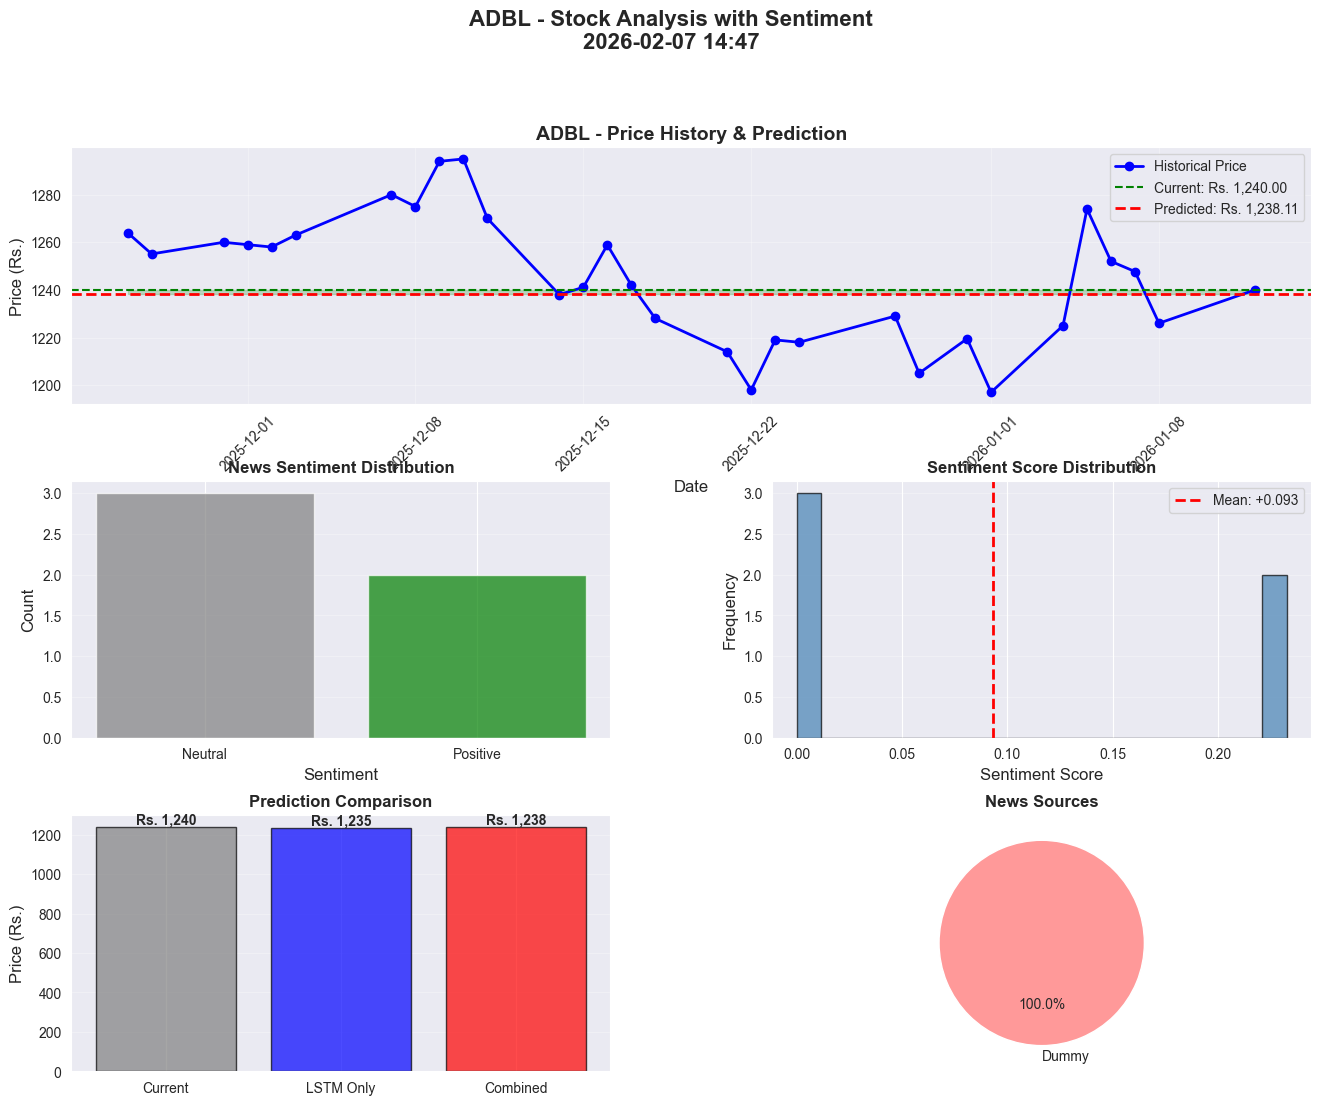

In [16]:
print("="*70)
print("📊 CREATING VISUALIZATIONS")
print("="*70)

if prediction_results is not None:
    # Create figure with subplots
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
    
    # 1. Price History with Prediction
    ax1 = fig.add_subplot(gs[0, :])
    last_30_days = stock_df.tail(30)
    ax1.plot(last_30_days['Date'], last_30_days['Close'], 
             linewidth=2, color='blue', label='Historical Price', marker='o')
    ax1.axhline(y=current_price, color='green', linestyle='--', 
                linewidth=1.5, label=f'Current: Rs. {current_price:,.2f}')
    ax1.axhline(y=combined_prediction, color='red', linestyle='--', 
                linewidth=2, label=f'Predicted: Rs. {combined_prediction:,.2f}')
    ax1.fill_between(last_30_days['Date'], current_price, combined_prediction, 
                      alpha=0.2, color='red' if combined_prediction > current_price else 'green')
    ax1.set_xlabel('Date', fontsize=12)
    ax1.set_ylabel('Price (Rs.)', fontsize=12)
    ax1.set_title(f'{CONFIG["COMPANY_SYMBOL"]} - Price History & Prediction', 
                  fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    
    # 2. Sentiment Distribution
    ax2 = fig.add_subplot(gs[1, 0])
    sentiment_counts = news_df['sentiment_label'].value_counts()
    colors = ['green' if l=='Positive' else 'red' if l=='Negative' else 'gray' 
              for l in sentiment_counts.index]
    ax2.bar(sentiment_counts.index, sentiment_counts.values, color=colors, alpha=0.7)
    ax2.set_xlabel('Sentiment', fontsize=12)
    ax2.set_ylabel('Count', fontsize=12)
    ax2.set_title('News Sentiment Distribution', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 3. Sentiment Scores Histogram
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.hist(news_df['sentiment_score'], bins=20, color='steelblue', alpha=0.7, edgecolor='black')
    ax3.axvline(x=avg_sentiment, color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {avg_sentiment:+.3f}')
    ax3.set_xlabel('Sentiment Score', fontsize=12)
    ax3.set_ylabel('Frequency', fontsize=12)
    ax3.set_title('Sentiment Score Distribution', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='y')
    
    # 4. Prediction Comparison
    ax4 = fig.add_subplot(gs[2, 0])
    predictions = ['Current', 'LSTM Only', 'Combined']
    values = [current_price, lstm_prediction, combined_prediction]
    colors_pred = ['gray', 'blue', 'red']
    bars = ax4.bar(predictions, values, color=colors_pred, alpha=0.7, edgecolor='black')
    ax4.set_ylabel('Price (Rs.)', fontsize=12)
    ax4.set_title('Prediction Comparison', fontsize=12, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'Rs. {height:,.0f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # 5. News Sources
    ax5 = fig.add_subplot(gs[2, 1])
    source_counts = news_df['source'].value_counts()
    ax5.pie(source_counts.values, labels=source_counts.index, autopct='%1.1f%%',
            startangle=90, colors=['#ff9999', '#66b3ff', '#99ff99'])
    ax5.set_title('News Sources', fontsize=12, fontweight='bold')
    
    # Main title
    fig.suptitle(f'{CONFIG["COMPANY_SYMBOL"]} - Stock Analysis with Sentiment\n{datetime.now().strftime("%Y-%m-%d %H:%M")}',
                 fontsize=16, fontweight='bold', y=0.995)
    
    plt.savefig(f'{CONFIG["COMPANY_SYMBOL"]}_analysis.png', dpi=300, bbox_inches='tight')
    print("\n✅ Visualization saved as PNG")
    
    plt.show()
else:
    print("\n⚠️  Cannot create visualizations without predictions")

## 💾 STEP 6: Save Results & Summary

In [17]:
print("="*70)
print("💾 SAVING RESULTS")
print("="*70)

if prediction_results is not None:
    # Save prediction summary
    summary_df = pd.DataFrame([prediction_results])
    summary_filename = f"{CONFIG['COMPANY_SYMBOL']}_prediction_summary.csv"
    
    # Append to existing or create new
    try:
        existing = pd.read_csv(summary_filename)
        summary_df = pd.concat([existing, summary_df], ignore_index=True)
    except:
        pass
    
    summary_df.to_csv(summary_filename, index=False)
    print(f"✅ Saved: {summary_filename}")
    
    # Save detailed report
    report_filename = f"{CONFIG['COMPANY_SYMBOL']}_detailed_report.txt"
    with open(report_filename, 'w', encoding='utf-8') as f:
        f.write(f"{'='*70}\n")
        f.write(f"STOCK PREDICTION REPORT - {CONFIG['COMPANY_SYMBOL']}\n")
        f.write(f"{'='*70}\n\n")
        f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
        
        f.write(f"CURRENT STATUS:\n")
        f.write(f"  Current Price: Rs. {current_price:,.2f}\n\n")
        
        f.write(f"PREDICTIONS:\n")
        f.write(f"  LSTM Model: Rs. {lstm_prediction:,.2f} ({lstm_change_pct:+.2f}%)\n")
        f.write(f"  Combined (with Sentiment): Rs. {combined_prediction:,.2f} ({combined_change_pct:+.2f}%)\n\n")
        
        f.write(f"SENTIMENT ANALYSIS:\n")
        f.write(f"  News Items Analyzed: {len(news_df)}\n")
        f.write(f"  Average Sentiment: {avg_sentiment:+.4f}\n")
        f.write(f"  Sentiment Distribution:\n")
        for label, count in news_df['sentiment_label'].value_counts().items():
            f.write(f"    {label}: {count}\n")
        
        f.write(f"\nTRADING SIGNAL: {signal}\n\n")
        
        f.write(f"TOP NEWS HEADLINES:\n")
        for idx, row in news_df.head(10).iterrows():
            emoji = row.get('sentiment_emoji', '')
            f.write(f"  {emoji} {row['headline']}\n")
    
    print(f"✅ Saved: {report_filename}")
    
    print("\n" + "="*70)
    print("✅ ALL COMPLETE!")
    print("="*70)
    print("\n📁 Files Generated:")
    print(f"  1. {CONFIG['COMPANY_SYMBOL']}_news_sentiment.csv")
    print(f"  2. {summary_filename}")
    print(f"  3. {report_filename}")
    print(f"  4. {CONFIG['COMPANY_SYMBOL']}_analysis.png")
else:
    print("\n⚠️  No predictions to save")

💾 SAVING RESULTS
✅ Saved: ADBL_prediction_summary.csv
✅ Saved: ADBL_detailed_report.txt

✅ ALL COMPLETE!

📁 Files Generated:
  1. ADBL_news_sentiment.csv
  2. ADBL_prediction_summary.csv
  3. ADBL_detailed_report.txt
  4. ADBL_analysis.png


## 📈 BONUS: Track Prediction Accuracy

In [18]:
# This cell helps you track how accurate your predictions are over time

def update_prediction_accuracy(predicted_price, actual_price, prediction_date):
    """
    Update prediction accuracy tracker
    """
    tracker_file = f"{CONFIG['COMPANY_SYMBOL']}_accuracy_tracker.csv"
    
    # Calculate metrics
    error = actual_price - predicted_price
    error_pct = (error / actual_price) * 100
    abs_error_pct = abs(error_pct)
    
    # Create record
    record = {
        'prediction_date': prediction_date,
        'actual_date': datetime.now().strftime('%Y-%m-%d'),
        'predicted_price': predicted_price,
        'actual_price': actual_price,
        'error': error,
        'error_percent': error_pct,
        'abs_error_percent': abs_error_pct
    }
    
    # Save or append
    try:
        tracker_df = pd.read_csv(tracker_file)
        tracker_df = pd.concat([tracker_df, pd.DataFrame([record])], ignore_index=True)
    except:
        tracker_df = pd.DataFrame([record])
    
    tracker_df.to_csv(tracker_file, index=False)
    
    # Calculate overall accuracy
    mean_abs_error = tracker_df['abs_error_percent'].mean()
    
    print("\n" + "="*70)
    print("📊 PREDICTION ACCURACY UPDATE")
    print("="*70)
    print(f"\n✅ Prediction tracked!")
    print(f"  Predicted: Rs. {predicted_price:,.2f}")
    print(f"  Actual: Rs. {actual_price:,.2f}")
    print(f"  Error: {error_pct:+.2f}%")
    print(f"\n📈 Overall Model Accuracy:")
    print(f"  Mean Absolute Error: {mean_abs_error:.2f}%")
    print(f"  Total Predictions Tracked: {len(tracker_df)}")
    print(f"\n💾 Updated: {tracker_file}")

# Example usage (uncomment when you have actual price):
# update_prediction_accuracy(
#     predicted_price=combined_prediction,
#     actual_price=350.00,  # Replace with actual next-day price
#     prediction_date=datetime.now().strftime('%Y-%m-%d')
# )

print("\n💡 To track accuracy:")
print("   1. Wait for next trading day")
print("   2. Get actual closing price")
print("   3. Run update_prediction_accuracy() with actual price")


💡 To track accuracy:
   1. Wait for next trading day
   2. Get actual closing price
   3. Run update_prediction_accuracy() with actual price
